# metro c620
deep dive into each activity

In [1]:
import os
import numpy as np 
from astropy.table import Table

In [2]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
data_binary = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/data_binary_act.hdf5')
metro = data_binary[data_binary['arch'] == 'metro']
YX_metro = np.array([np.array(metro[col]) for col in metro.colnames[:-2]]).T

In [5]:
def dY_jackknife(dY, zipcodes, func=np.median, njack=5): 
    ''' jackknife uncertainties 
    '''
    mu_dY = func(dY)
    
    mu_dY_jack, n_jack = [], 0
    for i in range(njack): 
        in_jack = ((zipcodes % njack) == i)
        if np.sum(in_jack) == 0: continue
            
        mu_dY_jack.append(func(dY[~in_jack]))
        n_jack += 1
    if n_jack < 3: return np.inf
    
    mu_dY_jack = np.array(mu_dY_jack)
    
    sig_jack = np.sqrt((n_jack - 1)/n_jack * np.sum((mu_dY_jack - mu_dY)**2))
    return sig_jack

## examine natural experiments

In [6]:
experiments = [(75, 107)]

In [7]:
all_ctes, all_zips = [], [] 

### experiment 1

In [8]:
# 75 - 107
exp_data = Table.read('/scratch/gpfs/chhahn/noah/noah2/exps/metro.75_107.hdf5')

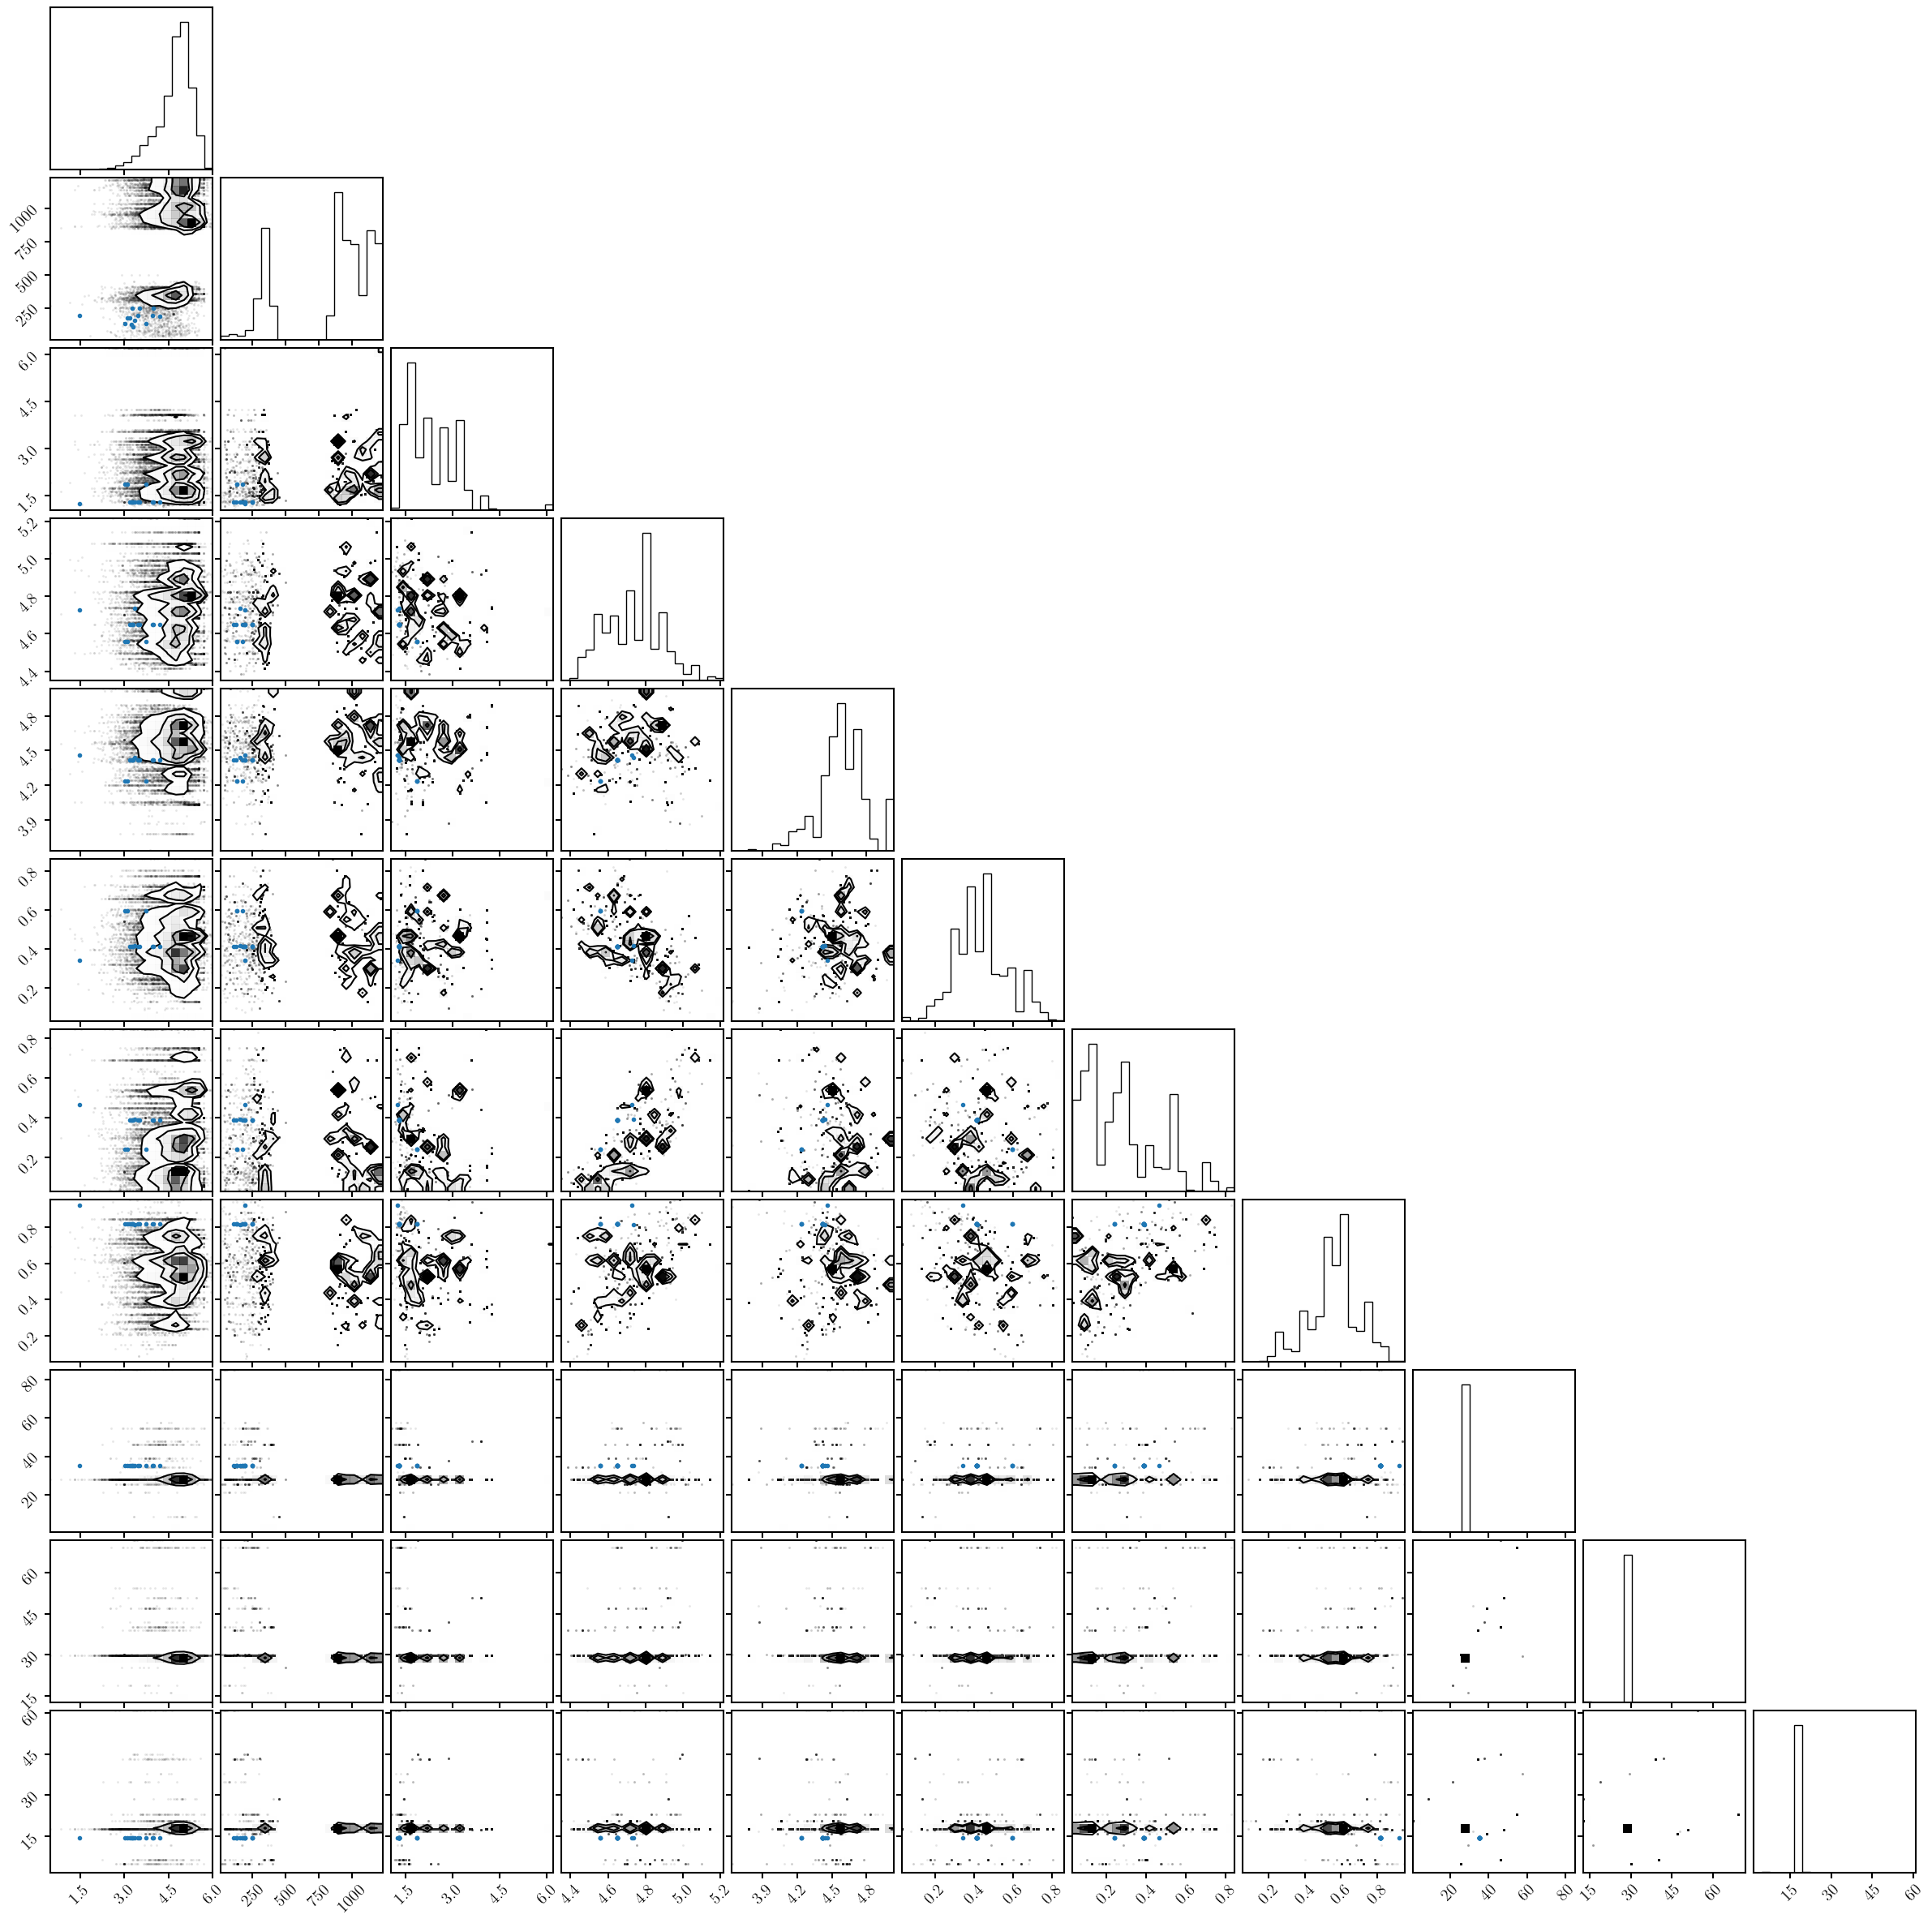

In [9]:
fig = DFM.corner(YX_metro[metro['binary_code'] == 75])

DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.95], color='C0')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.8], color='C1')
DFM.overplot_points(fig, np.concatenate([exp_data['Y_ref'], exp_data['X_ref']], axis=1)[exp_data['p_support'] < 0.5], color='r')

In [14]:
for thresh in [0.95, 0.9, 0.85, 0.8, 0.5]: 
    cut = (exp_data['p_support'] < thresh)
    print('%.2f \pm %.2f' % (np.median(exp_data['CTE'][cut]), dY_jackknife(exp_data['CTE'][cut], exp_data['zipcode'][cut], func=np.median, njack=5)))

-21196.17 \pm 910.59
-22130.14 \pm inf
nan \pm inf
nan \pm inf
nan \pm inf


In [15]:
cut = (exp_data['p_support'] < 0.95)
all_ctes.append(exp_data['CTE'][cut])
all_zips.append(exp_data['zipcode'][cut])

## combined

In [16]:
# get jackknife for single experiment
sig_jack = dY_jackknife(np.concatenate(all_ctes), np.concatenate(all_zips), func=np.median, njack=5)
print('  %.2f +/- %.2f' % (np.median(np.concatenate(all_ctes)), sig_jack))

  -21196.17 +/- 910.59
